# 基于机器学习的 Lorenz 混沌系统短期状态预测

本 Notebook 用 Lorenz 方程数值模拟生成数据，并完成数据处理、EDA、相关性热力图、StandardScaler 标准化、Baseline Model、随机森林主模型、MLP 可选模型、RMSE/MAE/R² 指标评价，以及真实值 vs 预测值散点图。


## 1. 导入依赖与全局设置

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import solve_ivp
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIGURES_DIR = Path("figures")
RESULTS_DIR = Path("results")
FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", font="SimHei")
plt.rcParams["axes.unicode_minus"] = False

## 2. 生成 Lorenz 系统数据

Lorenz 系统方程为：

$$
rac{dx}{dt}=\sigma(y-x),\quad
rac{dy}{dt}=x(ho-z)-y,\quad
rac{dz}{dt}=xy-eta z.
$$

本文采用经典参数 $\sigma=10, ho=28, eta=8/3$，并通过数值积分生成时间序列。


In [2]:
sigma = 10
rho = 28
beta = 8 / 3
initial_state = [1.0, 1.0, 1.0]
t_start, t_end = 0, 50
n_points = 10000
t_eval = np.linspace(t_start, t_end, n_points)

def lorenz_system(t, state, sigma=sigma, rho=rho, beta=beta):
    x, y, z = state
    dxdt = sigma * (y - x)
    dydt = x * (rho - z) - y
    dzdt = x * y - beta * z
    return [dxdt, dydt, dzdt]

solution = solve_ivp(
    lorenz_system,
    (t_start, t_end),
    initial_state,
    t_eval=t_eval,
    method="RK45",
    rtol=1e-9,
    atol=1e-12,
)

trajectory = pd.DataFrame({
    "time": solution.t,
    "x": solution.y[0],
    "y": solution.y[1],
    "z": solution.y[2],
})

trajectory.head()

,time,x,y,z
0,0.000000,1.000000,1.000000,1.000000
1,0.005001,1.003194,1.129853,0.992050
2,0.010001,1.012568,1.259946,0.984890
3,0.015002,1.027853,1.391089,0.978559
4,0.020002,1.048831,1.524054,0.973112


## 3. 构造监督学习数据集

为了让任务不过于简单，本文预测当前时刻之后 10 个采样步长的 $x$ 值。输入变量为当前状态 $x(t),y(t),z(t)$，预测目标为 $x(t+10\Delta t)$。


In [3]:
prediction_horizon = 10
supervised = pd.DataFrame({
    "x_t": trajectory["x"].iloc[:-prediction_horizon].to_numpy(),
    "y_t": trajectory["y"].iloc[:-prediction_horizon].to_numpy(),
    "z_t": trajectory["z"].iloc[:-prediction_horizon].to_numpy(),
    "x_next": trajectory["x"].iloc[prediction_horizon:].to_numpy(),
})

supervised.to_csv(RESULTS_DIR / "lorenz_supervised_dataset.csv", index=False)
print(f"数据集维度: {supervised.shape}")
supervised.head()

数据集维度: (9990, 4)


,x_t,y_t,z_t,x_next
0,1.000000,1.000000,1.000000,1.287610
1,1.003194,1.129853,0.992050,1.345925
2,1.012568,1.259946,0.984890,1.409649
3,1.027853,1.391089,0.978559,1.478892
4,1.048831,1.524054,0.973112,1.553798


## 4. 数据质量检查与描述统计

In [4]:
missing_values = supervised.isna().sum()
missing_values.to_csv(RESULTS_DIR / "missing_values.csv", header=["missing_count"])
print("各列缺失值数量：")
print(missing_values)

descriptive_stats = supervised.describe().T
selected_stats = descriptive_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]
selected_stats.to_csv(RESULTS_DIR / "descriptive_stats.csv")
selected_stats

各列缺失值数量：
x_t       0
y_t       0
z_t       0
x_next    0
dtype: int64


,mean,std,min,25%,50%,75%,max
x_t,-1.843041,7.852234,-17.299359,-8.100337,-3.178220,3.692126,19.563111
y_t,-1.877375,8.781791,-22.876345,-8.163097,-2.555521,3.228767,27.183572
z_t,24.175387,7.986239,0.961737,18.584724,24.308864,29.839885,47.834399
x_next,-1.858032,7.861055,-17.299359,-8.114466,-3.215900,3.692126,19.563111


## 5. 探索性数据分析与可视化

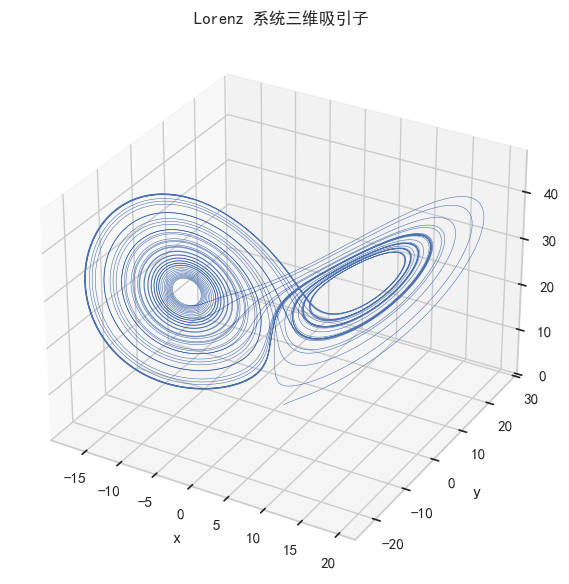

In [5]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot(trajectory["x"], trajectory["y"], trajectory["z"], linewidth=0.4)
ax.set_title("Lorenz 系统三维吸引子")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lorenz_attractor.png", dpi=300, bbox_inches="tight")
plt.show()

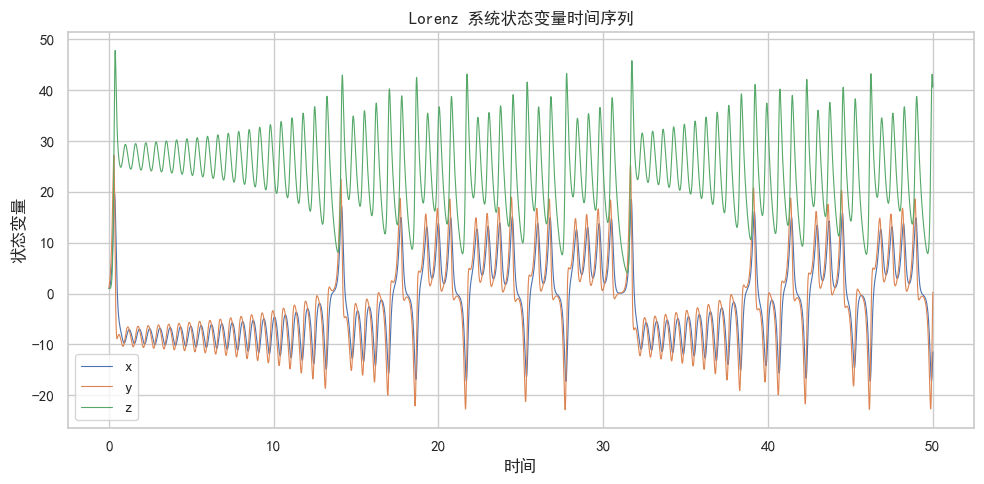

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(trajectory["time"], trajectory["x"], label="x", linewidth=0.8)
plt.plot(trajectory["time"], trajectory["y"], label="y", linewidth=0.8)
plt.plot(trajectory["time"], trajectory["z"], label="z", linewidth=0.8)
plt.xlabel("时间")
plt.ylabel("状态变量")
plt.title("Lorenz 系统状态变量时间序列")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "lorenz_time_series.png", dpi=300, bbox_inches="tight")
plt.show()

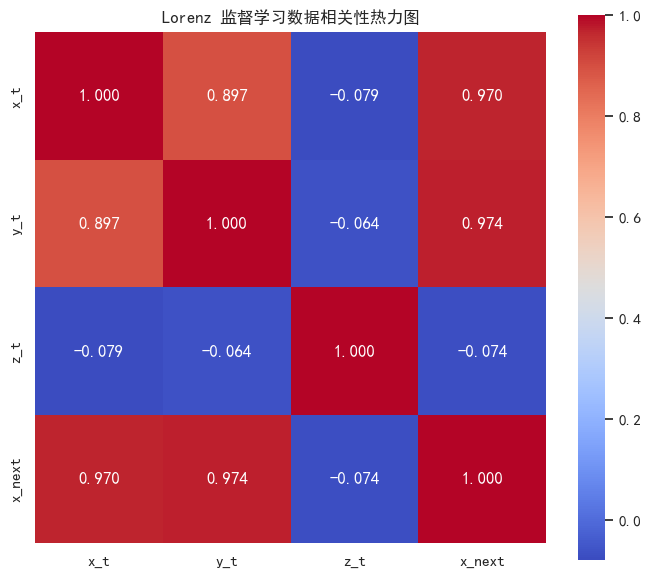

In [7]:
plt.figure(figsize=(7, 6))
corr = supervised.corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", square=True)
plt.title("Lorenz 监督学习数据相关性热力图")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. 训练集/测试集划分与 StandardScaler 标准化

为了尊重时间序列顺序，本文采用前 80% 样本作为训练集，后 20% 样本作为测试集。StandardScaler 只在训练集上 fit，再应用到训练集和测试集。


In [8]:
feature_cols = ["x_t", "y_t", "z_t"]
target_col = "x_next"

X = supervised[feature_cols].to_numpy()
y = supervised[target_col].to_numpy()

split_index = int(len(supervised) * 0.8)
X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

standardization_check = pd.DataFrame({
    "feature": feature_cols,
    "train_scaled_mean": X_train_scaled.mean(axis=0),
    "train_scaled_std": X_train_scaled.std(axis=0),
})
standardization_check.to_csv(RESULTS_DIR / "standardization_check.csv", index=False)

print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
standardization_check

训练集样本数: 7992
测试集样本数: 1998


,feature,train_scaled_mean,train_scaled_std
0,x_t,-2.845016e-17,1.0
1,y_t,0.000000e+00,1.0
2,z_t,-9.957556e-17,1.0


## 7. 模型训练与评价

In [9]:
def evaluate_regression(y_true, y_pred):
    return {
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "R2": float(r2_score(y_true, y_pred)),
    }

predictions = {}
metrics = {}

persistence_pred = X_test[:, 0]
predictions["Persistence"] = persistence_pred
metrics["Persistence"] = evaluate_regression(y_test, persistence_pred)

linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_pred = linear_model.predict(X_test_scaled)
predictions["Linear Regression"] = linear_pred
metrics["Linear Regression"] = evaluate_regression(y_test, linear_pred)

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=18,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
predictions["Random Forest"] = rf_pred
metrics["Random Forest"] = evaluate_regression(y_test, rf_pred)

mlp_model = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=600,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
mlp_model.fit(X_train_scaled, y_train)
mlp_pred = mlp_model.predict(X_test_scaled)
predictions["MLP"] = mlp_pred
metrics["MLP"] = evaluate_regression(y_test, mlp_pred)

metrics_df = pd.DataFrame(metrics).T
metrics_df.to_csv(RESULTS_DIR / "model_metrics.csv")
metrics_df

,RMSE,MAE,R2
Persistence,2.165343,1.765714,0.920785
Linear Regression,0.567887,0.455593,0.994552
Random Forest,0.088720,0.050448,0.999867
MLP,0.077883,0.057412,0.999898


## 8. 真实值 vs 预测值散点图

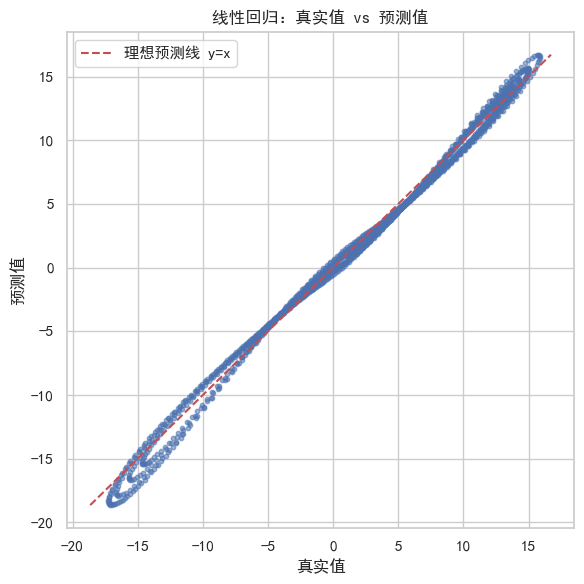

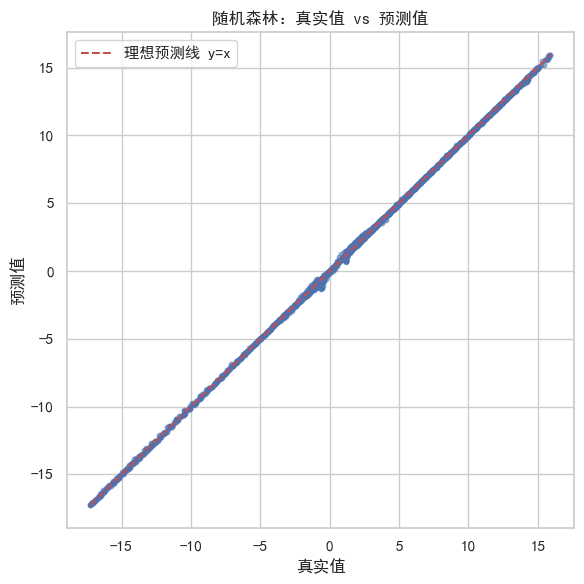

In [10]:
def plot_prediction_scatter(y_true, y_pred, title, filename):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, s=10, alpha=0.55)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=1.5, label="理想预测线 y=x")
    plt.xlabel("真实值")
    plt.ylabel("预测值")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=300, bbox_inches="tight")
    plt.show()

plot_prediction_scatter(y_test, linear_pred, "线性回归：真实值 vs 预测值", "prediction_scatter_linear.png")
plot_prediction_scatter(y_test, rf_pred, "随机森林：真实值 vs 预测值", "prediction_scatter_rf.png")

## 9. 时间序列预测对比、残差与模型对比图

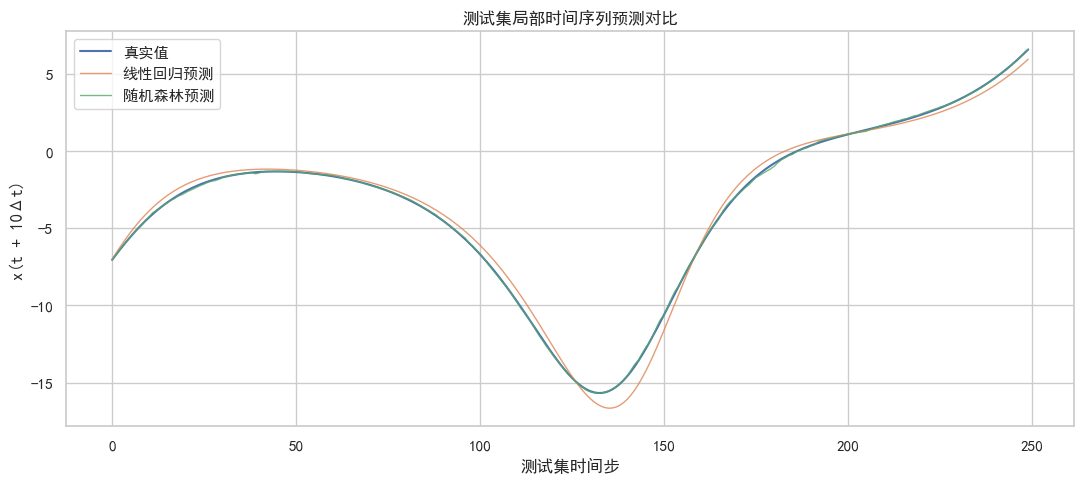

In [11]:
n_display = 250
plt.figure(figsize=(11, 5))
plt.plot(y_test[:n_display], label="真实值", linewidth=1.5)
plt.plot(linear_pred[:n_display], label="线性回归预测", linewidth=1.0, alpha=0.8)
plt.plot(rf_pred[:n_display], label="随机森林预测", linewidth=1.0, alpha=0.8)
plt.xlabel("测试集时间步")
plt.ylabel("x(t + 10Δt)")
plt.title("测试集局部时间序列预测对比")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "time_series_prediction.png", dpi=300, bbox_inches="tight")
plt.show()

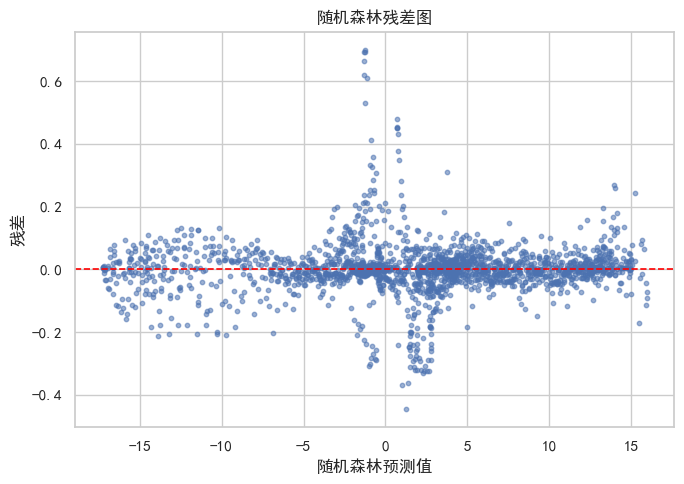

In [12]:
residuals = y_test - rf_pred
plt.figure(figsize=(7, 5))
plt.scatter(rf_pred, residuals, s=10, alpha=0.55)
plt.axhline(0, color="red", linestyle="--", linewidth=1.2)
plt.xlabel("随机森林预测值")
plt.ylabel("残差")
plt.title("随机森林残差图")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "residuals.png", dpi=300, bbox_inches="tight")
plt.show()

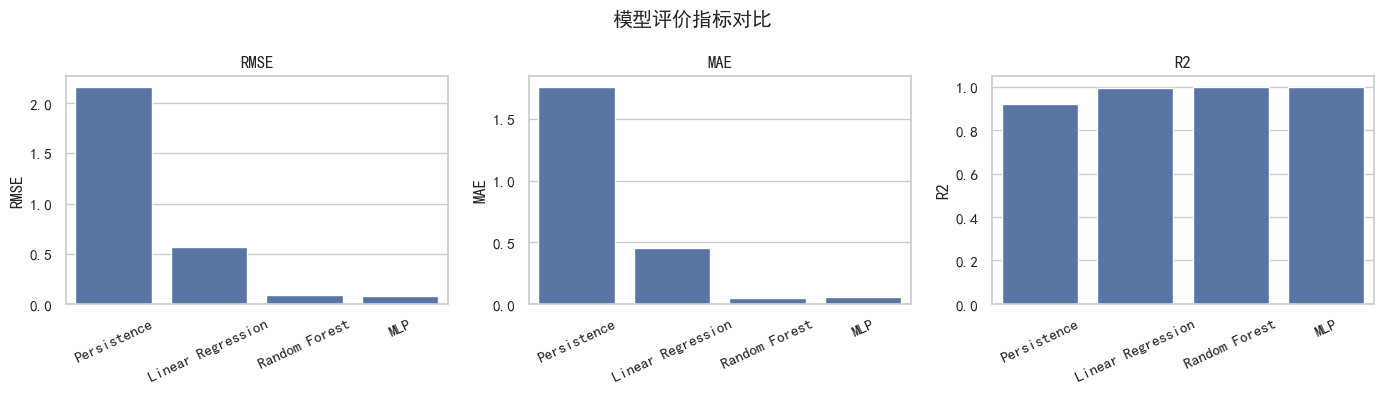

In [13]:
metrics_plot = metrics_df.reset_index().rename(columns={"index": "model"})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    sns.barplot(data=metrics_plot, x="model", y=metric, ax=ax)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("模型评价指标对比")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "model_metrics_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

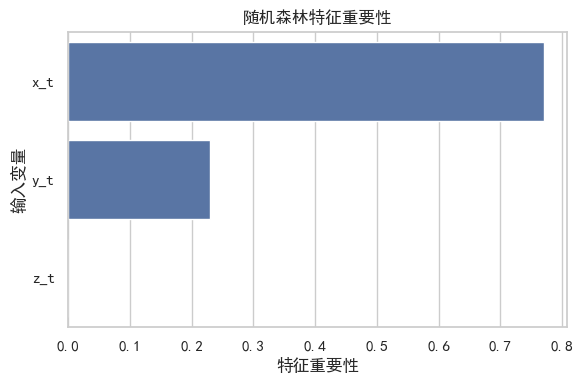

,feature,importance
0,x_t,0.770017
1,y_t,0.229809
2,z_t,0.000174


In [14]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_,
}).sort_values("importance", ascending=False)
importance_df.to_csv(RESULTS_DIR / "feature_importance.csv", index=False)

plt.figure(figsize=(6, 4))
sns.barplot(data=importance_df, x="importance", y="feature")
plt.xlabel("特征重要性")
plt.ylabel("输入变量")
plt.title("随机森林特征重要性")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()
importance_df

## 10. 导出报告回填所需摘要

In [15]:
summary = {
    "sigma": sigma,
    "rho": rho,
    "beta": beta,
    "initial_state": initial_state,
    "t_start": t_start,
    "t_end": t_end,
    "n_points": n_points,
    "prediction_horizon": prediction_horizon,
    "delta_t": float(t_eval[1] - t_eval[0]),
    "effective_prediction_time": float((t_eval[1] - t_eval[0]) * prediction_horizon),
    "dataset_rows": int(len(supervised)),
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "missing_values": {k: int(v) for k, v in missing_values.to_dict().items()},
    "metrics": metrics,
}

with open(RESULTS_DIR / "summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'sigma': 10,
 'rho': 28,
 'beta': 2.6666666666666665,
 'initial_state': [1.0, 1.0, 1.0],
 't_start': 0,
 't_end': 50,
 'n_points': 10000,
 'prediction_horizon': 10,
 'delta_t': 0.005000500050005001,
 'effective_prediction_time': 0.05000500050005001,
 'dataset_rows': 9990,
 'train_rows': 7992,
 'test_rows': 1998,
 'missing_values': {'x_t': 0, 'y_t': 0, 'z_t': 0, 'x_next': 0},
 'metrics': {'Persistence': {'RMSE': 2.1653426784085683,
   'MAE': 1.7657140367272708,
   'R2': 0.9207854046804976},
  'Linear Regression': {'RMSE': 0.5678866495694991,
   'MAE': 0.4555931419186525,
   'R2': 0.9945515213403179},
  'Random Forest': {'RMSE': 0.08872027243990131,
   'MAE': 0.05044844536849938,
   'R2': 0.9998670165273196},
  'MLP': {'RMSE': 0.07788330708130353,
   'MAE': 0.05741184416633165,
   'R2': 0.9998975196252782}}}